In [1]:
!python --version

Python 3.13.5


In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('car_sales_new.csv')
df.head(10)

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN
5,Nissan,16600.0,crossover,83,2.0,Petrol,yes,2013,X-Trail,full
6,Honda,6500.0,sedan,199,2.0,Petrol,yes,2003,Accord,front
7,Renault,10500.0,vagon,185,1.5,Diesel,yes,2011,Megane,front
8,Mercedes-Benz,21500.0,sedan,146,1.8,Gas,yes,2012,E-Class,rear
9,Mercedes-Benz,22700.0,sedan,125,2.2,Diesel,yes,2010,E-Class,rear


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9065 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


In [4]:
df.isnull().sum()

car               0
price             0
body              0
mileage           0
engV            434
engType           0
registration      0
year              0
model             0
drive           511
dtype: int64

In [5]:
per = (df.isnull().sum() / df.isnull().count())
per

car             0.000000
price           0.000000
body            0.000000
mileage         0.000000
engV            0.045322
engType         0.000000
registration    0.000000
year            0.000000
model           0.000000
drive           0.053363
dtype: float64

In [21]:
df.describe()

,price,mileage,engv,year
count,9576.000000,9576.000000,9576.000000,9576.000000
mean,16069.208682,138.862364,2.646344,2006.605994
std,23960.786951,98.629754,5.791801,7.067924
min,259.350000,0.000000,0.100000,1953.000000
25%,5500.000000,70.000000,1.600000,2004.000000
50%,9800.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.646344,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [7]:
df.price[df.price== 0].count()

np.int64(267)

In [8]:
df.mileage[df.mileage== 0].count()

np.int64(348)

In [9]:
df.columns =(df.columns.str.lower())
df.columns

Index(['car', 'price', 'body', 'mileage', 'engv', 'engtype', 'registration',
       'year', 'model', 'drive'],
      dtype='object')

In [10]:
df

,car,price,body,mileage,engv,engtype,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN
...,...,...,...,...,...,...,...,...,...,...
9571,Hyundai,14500.0,crossover,140,2.0,Gas,yes,2011,Tucson,front
9572,Volkswagen,2200.0,vagon,150,1.6,Petrol,yes,1986,Passat B2,front
9573,Mercedes-Benz,18500.0,crossover,180,3.5,Petrol,yes,2008,ML 350,full
9574,Lexus,16999.0,sedan,150,3.5,Gas,yes,2008,ES 350,front


In [13]:
df.drive = df.drive.fillna('UnSpecified')
df.drive.unique()

array(['full', 'rear', 'front', 'UnSpecified'], dtype=object)

In [18]:
df.engv.fillna(df.engv.mean() , inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engv          9576 non-null   float64
 5   engtype       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9576 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


C:\Users\PC_KH\AppData\Local\Temp\ipykernel_11172\2594871843.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.engv.fillna(df.engv.mean() , inplace=True)


In [20]:
df.price = df.price.replace(0 , df.price.mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engv          9576 non-null   float64
 5   engtype       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9576 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


In [24]:
df['mileage_level'] = ['high mileage' if i > df.mileage.mean() else 'low mileage' for i in df.mileage]
df

,car,price,body,mileage,engv,engtype,registration,year,model,drive,mileage_level
0,Ford,15500.0,crossover,68,2.500000,Gas,yes,2010,Kuga,full,low mileage
1,Mercedes-Benz,20500.0,sedan,173,1.800000,Gas,yes,2011,E-Class,rear,high mileage
2,Mercedes-Benz,35000.0,other,135,5.500000,Petrol,yes,2008,CL 550,rear,low mileage
3,Mercedes-Benz,17800.0,van,162,1.800000,Diesel,yes,2012,B 180,front,high mileage
4,Mercedes-Benz,33000.0,vagon,91,2.646344,Other,yes,2013,E-Class,UnSpecified,low mileage
...,...,...,...,...,...,...,...,...,...,...,...
9571,Hyundai,14500.0,crossover,140,2.000000,Gas,yes,2011,Tucson,front,high mileage
9572,Volkswagen,2200.0,vagon,150,1.600000,Petrol,yes,1986,Passat B2,front,high mileage
9573,Mercedes-Benz,18500.0,crossover,180,3.500000,Petrol,yes,2008,ML 350,full,high mileage
9574,Lexus,16999.0,sedan,150,3.500000,Gas,yes,2008,ES 350,front,high mileage


<Axes: xlabel='model'>

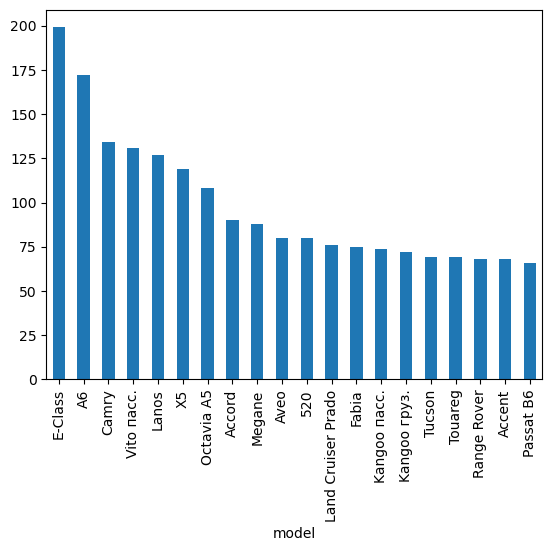

In [26]:
df.model.value_counts().head(20).plot.bar()

<Axes: xlabel='year'>

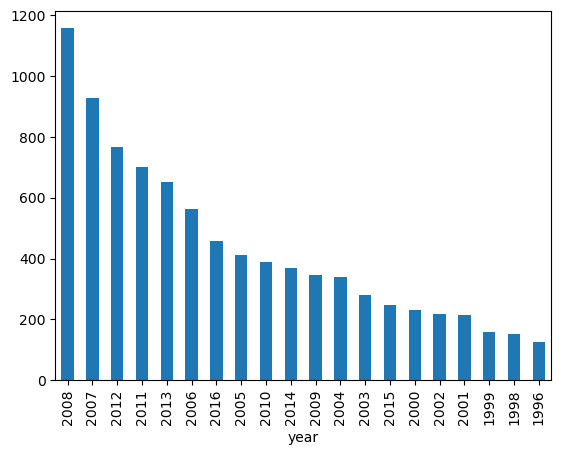

In [27]:
df.year.value_counts().head(20).plot.bar()

<Axes: xlabel='body'>

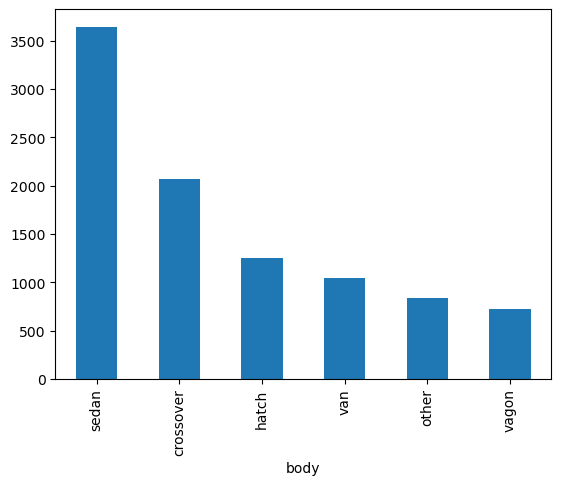

In [28]:
df.body.value_counts().head(20).plot.bar()

<Axes: xlabel='car'>

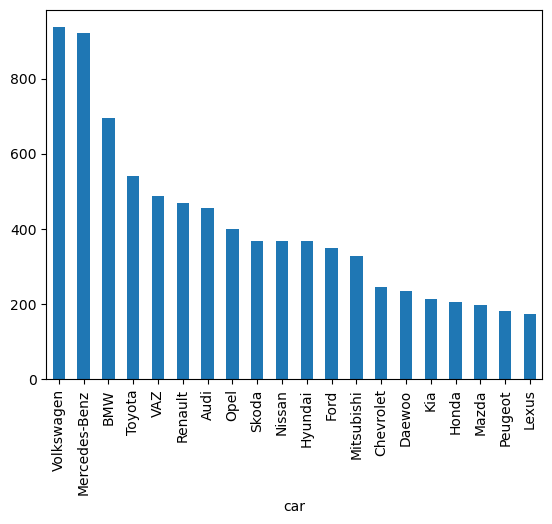

In [29]:
df.car.value_counts().head(20).plot.bar()

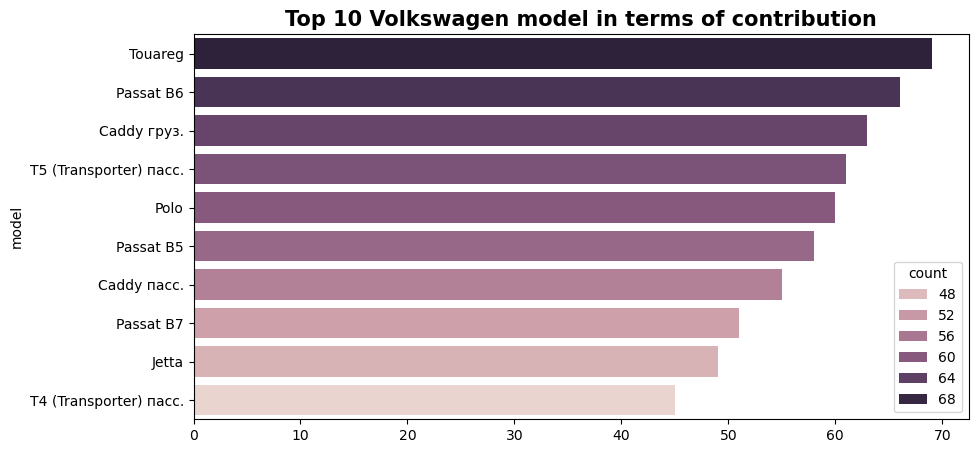

In [58]:
fig = plt.subplots(figsize=(10,5))
use =df[df['car'] == 'Volkswagen']['model'].value_counts().head(10)
sns.barplot(x=use , y=use.index , hue=use)
plt.title('Top 10 Volkswagen model in terms of contribution' , fontsize=15 , fontweight='bold')
plt.xlabel('')
plt.show()

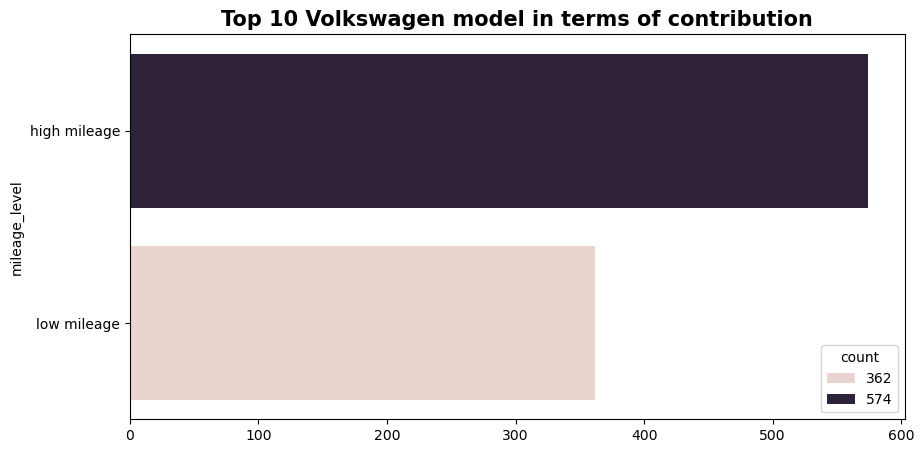

In [71]:
fig = plt.subplots(figsize=(10,5))
use =df[df['car'] == 'Volkswagen']['mileage_level'].value_counts().head(10)
sns.barplot(x=use , y=use.index , hue=use)
plt.title('Top 10 Volkswagen model in terms of contribution' , fontsize=15 , fontweight='bold')
plt.xlabel('')
plt.show()

In [74]:
st = pd.value_counts(df.engtype.values , sort=False)
st

C:\Users\PC_KH\AppData\Local\Temp\ipykernel_11172\1551132637.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  st = pd.value_counts(df.engtype.values , sort=False)


Gas       1722
Petrol    4379
Diesel    3013
Other      462
Name: count, dtype: int64

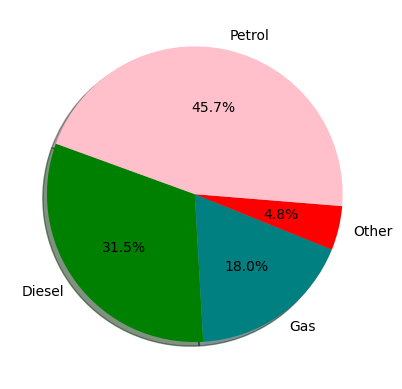

In [109]:
size = df.engtype.value_counts(sort=False)
labels = df.engtype.unique()
labels.sort()
size.sort_index(inplace=True)
colors = ['green' , 'teal' , 'red' , 'pink']
plt.pie(size , labels=labels , colors = colors , autopct='%1.1f%%' ,startangle =160 , shadow=True)
plt.show()

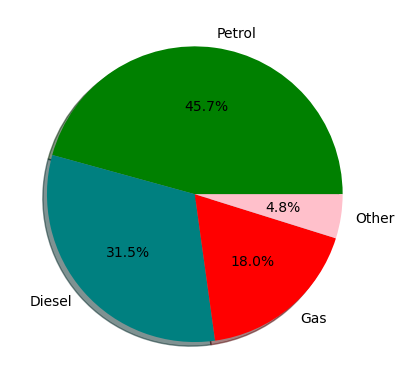

In [116]:
sizes = df['engtype'].value_counts().sort_index()
colors = ['green' , 'teal' , 'red' , 'pink']
plt.pie(size , labels=size.index , colors = colors , autopct='%1.1f%%' ,startangle =0 , shadow=True)
plt.show()

In [112]:
size.unique

<bound method Series.unique of engtype
Petrol    4379
Diesel    3013
Gas       1722
Other      462
Name: count, dtype: int64>

In [93]:
labels

array(['Diesel', 'Gas', 'Other', 'Petrol'], dtype=object)